<a href="https://colab.research.google.com/github/FranMoritz/An-lise-Explorat-ria-de-Marketing-e-Score/blob/main/An%C3%A1lise_Explorat%C3%B3ria_de_Marketing_e_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análise Exploratória de Marketing e Score**


---

Pergunta de negócio: Como podemos redistribuir os investimentos de marketing nos próximos 6 meses para aumentar em 30% a aquisição de clientes com score a cima de 700, sem explodir o CAC e sem reduzir o volume total de contas abertas?

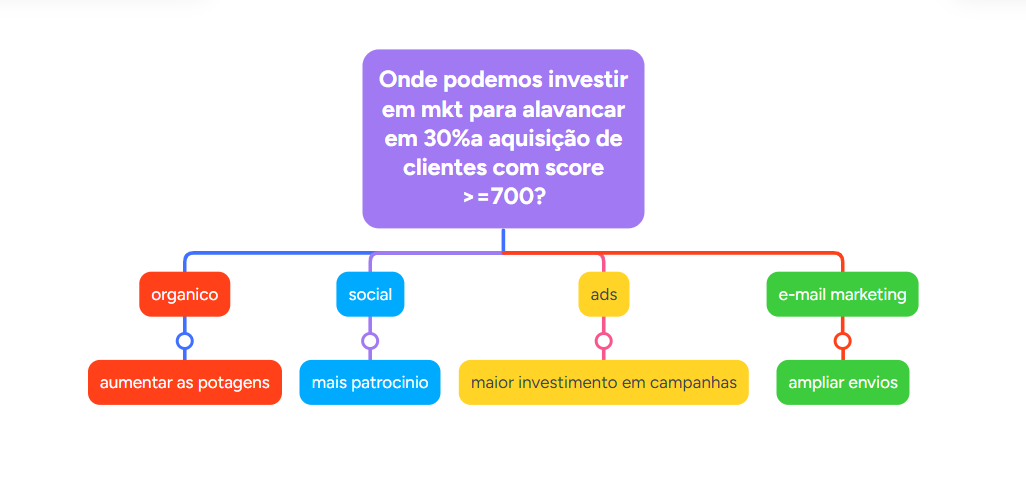

In [34]:
#acessando o drive
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [35]:
#importando as libs usadas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [36]:
#chamando a tabela aquisicao
df_aquisicao = pd.read_csv("/content/gdrive/My Drive/campanha_banco/fato_aquisicao_5000.csv",
                            delimiter=',',
                            encoding= 'utf-8'#'latin1' 'utf-8' 'latin1'
                            )

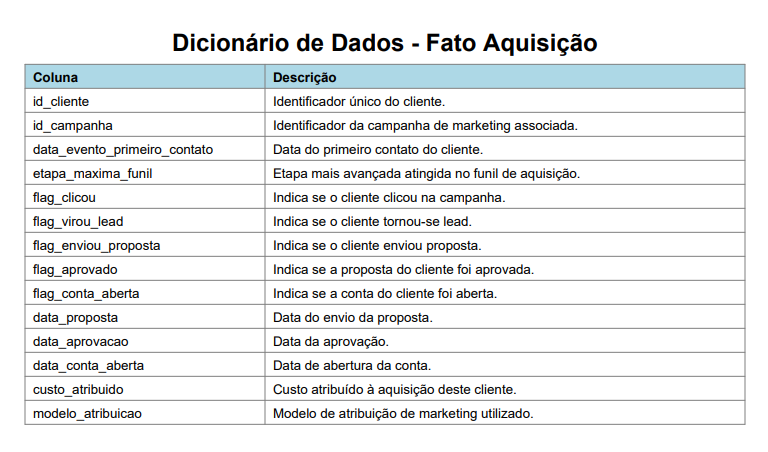

In [37]:
df_aquisicao.shape

(5000, 14)

In [39]:
#chamando a tabela cliente
df_cliente = pd.read_csv("/content/gdrive/My Drive/campanha_banco/dim_cliente_5000.csv",
                            delimiter=',',
                            encoding= 'utf-8'#'latin1' 'utf-8' 'latin1'
                            )

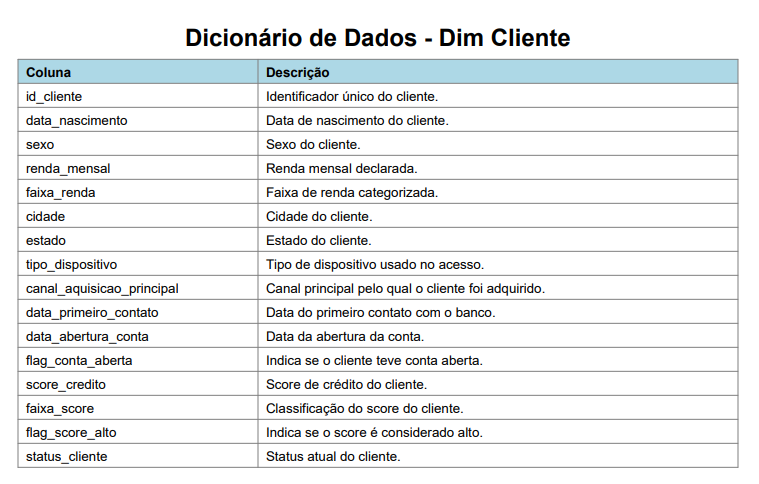

In [40]:
df_cliente.shape

(5000, 16)

In [42]:
#chamando a tabela campanha
df_campanha = pd.read_csv("/content/gdrive/My Drive/campanha_banco/dim_campanha_5000.csv",
                            delimiter=',',
                            encoding= 'utf-8'#'latin1' 'utf-8' 'latin1'
                            )

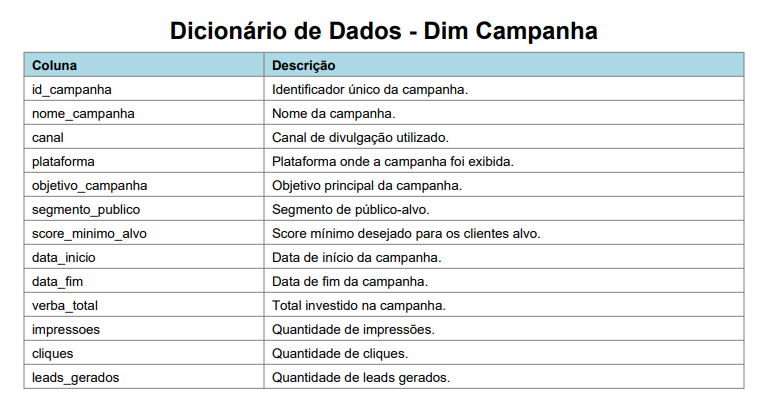

In [43]:
df_campanha.shape

(20, 13)

# **Criando uma única ABT**

In [45]:
# Deduplicando as tabelas que iremos fazer os joins
df_cliente_dedup = df_cliente.drop_duplicates(subset="id_cliente", keep="first")
df_campanha_dedup = df_campanha.drop_duplicates(subset="id_campanha", keep="first")


In [46]:
# LEFT JOIN 1: df_aquisicao + df_cliente (DF_AQUISICAO É A PRINCIPAL)
abt = df_aquisicao.merge(
    df_cliente_dedup,
    how="left",
    left_on="id_cliente",
    right_on="id_cliente"
)

print("\nApós join com cliente:", abt.shape)



Após join com cliente: (5000, 29)


In [47]:
# LEFT JOIN 2: (a tabela acima) + campanha

abt = abt.merge(
    df_campanha_dedup,
    how="left",
    left_on="id_campanha",
    right_on="id_campanha"
)

print("\nApós join com campanha:", abt.shape)

abt.head()


Após join com campanha: (5000, 41)


,id_cliente,id_campanha,data_evento_primeiro_contato,etapa_maxima_funil,flag_clicou,flag_virou_lead,flag_enviou_proposta,flag_aprovado,flag_conta_aberta_x,data_proposta,...,plataforma,objetivo_campanha,segmento_publico,score_minimo_alvo,data_inicio,data_fim,verba_total,impressoes,cliques,leads_gerados
0,CLI0001,NaN,2025-10-15,conta_aberta,1.0,1.0,1.0,1.0,1.0,2025-09-19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CLI0002,CAMP014,2025-11-27,lead,1.0,1.0,0.0,0.0,0.0,NaN,...,email,cross_sell,renda_media,600.0,2025-10-02,2026-01-06,165486.0,1886305.0,232254.0,73754.0
2,CLI0003,CAMP002,2025-09-30,aprovado,1.0,1.0,1.0,1.0,0.0,2025-10-09,...,tiktok,cross_sell,geral,600.0,2025-11-08,2025-12-29,151514.0,5431781.0,392504.0,78117.0
3,CLI0004,NaN,2025-11-22,conta_aberta,1.0,1.0,1.0,1.0,1.0,2025-10-28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CLI0005,CAMP014,2025-10-13,lead,1.0,1.0,0.0,NaN,0.0,NaN,...,email,cross_sell,renda_media,600.0,2025-10-02,2026-01-06,165486.0,1886305.0,232254.0,73754.0


# **Metadados**

In [48]:
# Visualização dos metadados
def generate_metadata(dataframe):
    """
    Gera um dataframe contendo metadados das colunas do dataframe fornecido.

    :param dataframe: DataFrame para o qual os metadados serão gerados.
    :return: DataFrame contendo metadados.
    """

    # Coleta de metadados básicos
    metadata = pd.DataFrame({
        'nome_variavel': dataframe.columns,
        'tipo': dataframe.dtypes,
        'qt_nulos': dataframe.isnull().sum(),
        'percent_nulos': round((dataframe.isnull().sum() / len(dataframe))* 100,2),
        'cardinalidade': dataframe.nunique(),
    })
    metadata=metadata.sort_values(by='tipo')
    metadata = metadata.reset_index(drop=True)

    return metadata

# Testando a função com o dataframe
metadata_df = generate_metadata(abt)
metadata_df

,nome_variavel,tipo,qt_nulos,percent_nulos,cardinalidade
0,leads_gerados,float64,250,5.00,20
1,cliques,float64,250,5.00,20
2,flag_score_alto,float64,629,12.58,2
3,renda_mensal,float64,629,12.58,8
4,custo_atribuido,float64,250,5.00,4208
5,score_credito,float64,634,12.68,697
6,score_minimo_alvo,float64,250,5.00,4
7,flag_conta_aberta_x,float64,250,5.00,2
8,flag_conta_aberta_y,float64,637,12.74,2
9,flag_enviou_proposta,float64,250,5.00,2


In [57]:
# Remover colunas com mais de 50% de nulos

# Calcula proporção de nulos por coluna
percent_nulls = abt.isnull().mean()

# Identifica colunas com >50% de nulos
cols_drop = percent_nulls[percent_nulls > 0.50].index.tolist()

print("Colunas com mais de 50% de nulos:")
for c in cols_drop:
    print(c)

# Remove essas colunas da ABT
abt_clean = abt.drop(columns=cols_drop)

print("\nShape antes:", abt.shape)
print("Shape depois:", abt_clean.shape)


Colunas com mais de 50% de nulos:
data_proposta
data_aprovacao
data_conta_aberta
data_abertura_conta

Shape antes: (5000, 41)
Shape depois: (5000, 37)


In [53]:
# Preenchimento de nulos por tipo ---> Object = 'não consta' e float64 = 9999


abt_filled = abt_clean.copy()

# Identificar colunas numéricas float64
float_cols = abt_filled.select_dtypes(include=["float64"]).columns

# Identificar colunas categóricas/strings
object_cols = abt_filled.select_dtypes(include=["object"]).columns

print("Colunas float preenchidas com 9999:")
print(float_cols.tolist())

print("\nColunas object preenchidas com 'não consta':")
print(object_cols.tolist())

# Preencher
abt_filled[float_cols] = abt_filled[float_cols].fillna(9999)
abt_filled[object_cols] = abt_filled[object_cols].fillna("não consta")

# Conferência final de nulos
print("\nNulos restantes após preenchimento:")
display(abt_filled.isnull().sum())


Colunas float preenchidas com 9999:
['flag_clicou', 'flag_virou_lead', 'flag_enviou_proposta', 'flag_aprovado', 'flag_conta_aberta_x', 'custo_atribuido', 'renda_mensal', 'flag_conta_aberta_y', 'score_credito', 'flag_score_alto', 'score_minimo_alvo', 'verba_total', 'impressoes', 'cliques', 'leads_gerados']

Colunas object preenchidas com 'não consta':
['id_cliente', 'id_campanha', 'data_evento_primeiro_contato', 'etapa_maxima_funil', 'modelo_atribuicao', 'data_nascimento', 'sexo', 'faixa_renda', 'cidade', 'estado', 'tipo_dispositivo', 'canal_aquisicao_principal', 'data_primeiro_contato', 'faixa_score', 'status_cliente', 'nome_campanha', 'canal', 'plataforma', 'objetivo_campanha', 'segmento_publico', 'data_inicio', 'data_fim']

Nulos restantes após preenchimento:


,0
id_cliente,0
id_campanha,0
data_evento_primeiro_contato,0
etapa_maxima_funil,0
flag_clicou,0
flag_virou_lead,0
flag_enviou_proposta,0
flag_aprovado,0
flag_conta_aberta_x,0
custo_atribuido,0


# **Análise Descritiva**

In [58]:
abt.describe(include='all')

,id_cliente,id_campanha,data_evento_primeiro_contato,etapa_maxima_funil,flag_clicou,flag_virou_lead,flag_enviou_proposta,flag_aprovado,flag_conta_aberta_x,data_proposta,...,plataforma,objetivo_campanha,segmento_publico,score_minimo_alvo,data_inicio,data_fim,verba_total,impressoes,cliques,leads_gerados
count,4750,4750,4750,4750,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,2375,...,4750,4750,4750,4750.000000,4750,4750,4750.000000,4.750000e+03,4750.000000,4750.000000
unique,4750,20,90,6,NaN,NaN,NaN,NaN,NaN,50,...,5,3,3,NaN,17,17,NaN,NaN,NaN,NaN
top,CLI5000,CAMP017,2025-10-05,clique,NaN,NaN,NaN,NaN,NaN,2025-10-26,...,tiktok,abertura_conta,geral,NaN,2025-08-28,2025-11-28,NaN,NaN,NaN,NaN
freq,1,260,75,843,NaN,NaN,NaN,NaN,NaN,62,...,1220,1711,1917,NaN,491,500,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,0.842947,0.666526,0.497053,0.332421,0.166947,NaN,...,NaN,NaN,NaN,625.831579,NaN,NaN,125672.507158,3.700906e+06,195430.354316,46376.272211
std,NaN,NaN,NaN,NaN,0.363889,0.471504,0.500044,0.471131,0.372968,NaN,...,NaN,NaN,NaN,46.209137,NaN,NaN,53750.696487,2.292601e+06,113760.362254,22803.304041
min,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,NaN,NaN,NaN,550.000000,NaN,NaN,21360.000000,2.598670e+05,23308.000000,7321.000000
25%,NaN,NaN,NaN,NaN,1.000000,0.000000,0.000000,0.000000,0.000000,NaN,...,NaN,NaN,NaN,600.000000,NaN,NaN,94043.000000,2.069401e+06,102038.000000,31489.000000
50%,NaN,NaN,NaN,NaN,1.000000,1.000000,0.000000,0.000000,0.000000,NaN,...,NaN,NaN,NaN,650.000000,NaN,NaN,146011.000000,3.723363e+06,179961.000000,55535.000000
75%,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,0.000000,NaN,...,NaN,NaN,NaN,650.000000,NaN,NaN,162617.000000,5.431781e+06,303449.000000,62541.000000


# **Análise Exploratória**

---

# **Como está a distribuição do Score?**

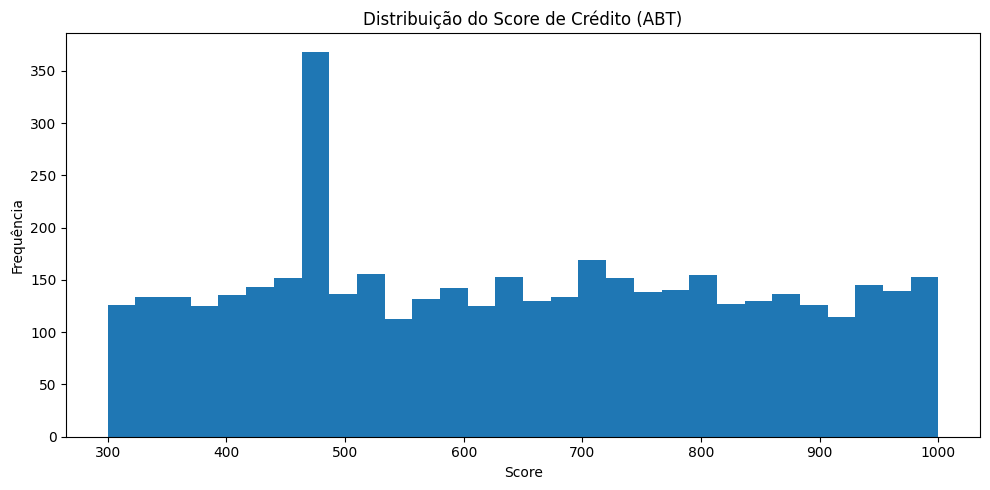

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(abt["score_credito"], bins=30)
plt.title("Distribuição do Score de Crédito (ABT)")
plt.xlabel("Score")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()


As faixas de score estão bem distribuídas, com um pico em torno de 480.
Esse pico pode indicar um segmento de clientes “indistintos” que podem estar vindo de um canal específico. Pode mostrar um canal que está trazendo muita gente com score médio, o que pode estar “achatando” a performance.

In [60]:
abt[abt["score_credito"] == 480]["canal_aquisicao_principal"].value_counts()


,count
canal_aquisicao_principal,
organico,5
email_marketing,2
social,1
google_ads,1


o canal orgânico está trazendo clientes com score mais baixo, pode significar que o conteúdo das campanhas não está bem direcionado. Como não é um canal pago, podemos alinhar com a equipe de marketing.

# **Proporção de clientes com score > 700 por canal**

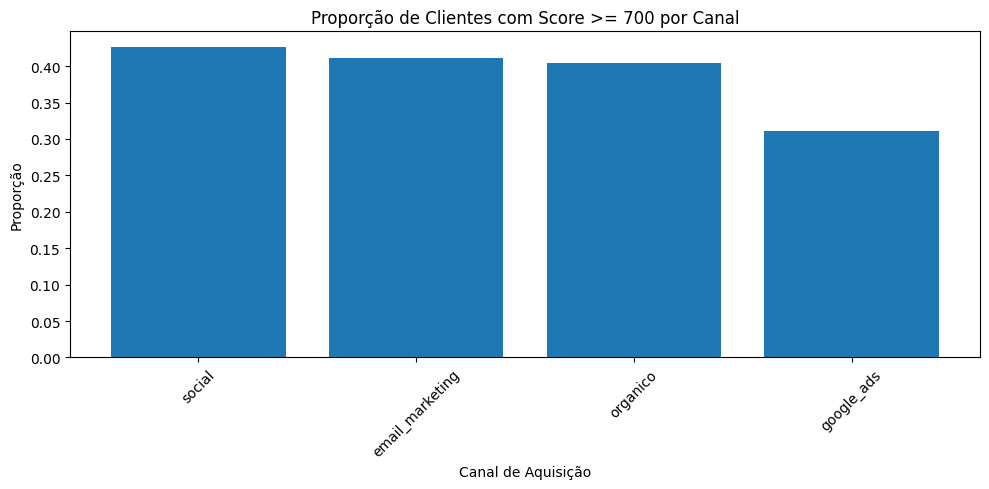

,score_alto
canal_aquisicao_principal,
social,0.426485
email_marketing,0.411153
organico,0.404419
google_ads,0.311382


In [67]:
# Criar coluna auxiliar indicando score alto
abt["score_alto"] = abt["score_credito"] >= 700

# Calcular proporção por canal
prop_por_canal = abt.groupby("canal_aquisicao_principal")["score_alto"].mean().sort_values(ascending=False)

# Plotar gráfico
plt.figure(figsize=(10,5))
plt.bar(prop_por_canal.index, prop_por_canal.values)
plt.title("Proporção de Clientes com Score >= 700 por Canal")
plt.xlabel("Canal de Aquisição")
plt.ylabel("Proporção")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Mostrar valores numéricos
prop_por_canal


Redes sociais é o canal que tende a trazer um público mais robisto financeiramente, seguid do e-mail marketing, onde campanhas de e-mail têm boa segmentação.

# **CAC mpedio por canal**

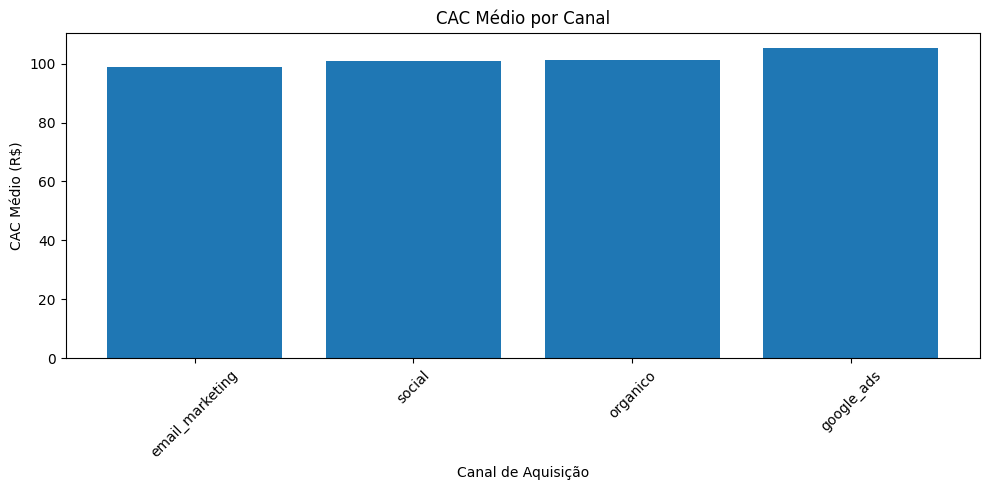

,custo_atribuido
canal_aquisicao_principal,
email_marketing,98.874454
social,100.990742
organico,101.127570
google_ads,105.155065


In [62]:
# calcular cac médio por canal
cac_por_canal = abt.groupby("canal_aquisicao_principal")["custo_atribuido"].mean().sort_values()

# plotar o gráfico
plt.figure(figsize=(10,5))
plt.bar(cac_por_canal.index, cac_por_canal.values)
plt.title("CAC Médio por Canal")
plt.xlabel("Canal de Aquisição")
plt.ylabel("CAC Médio (R$)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# opcional: visualizar os valores no output
cac_por_canal

Email Marketing aparece como o canal mais eficiente do ponto de vista de custo, registrando o menor CAC médio da base.

Social e Orgânico mantêm CACs muito semelhantes entre si, ambos levemente acima do Email Marketing, mas ainda dentro de um intervalo competitivo.

Google Ads apresenta o CAC mais elevado, sendo o canal com maior custo por cliente adquirido.

Google Ads combina o menor percentual de clientes com score alto com o maior CAC, indicando um canal potencialmente menos eficiente na estratégia atual e que merece revisão ou ajuste de segmentação.

# **matriz comparando eficiência × qualidade (score ≥700)**

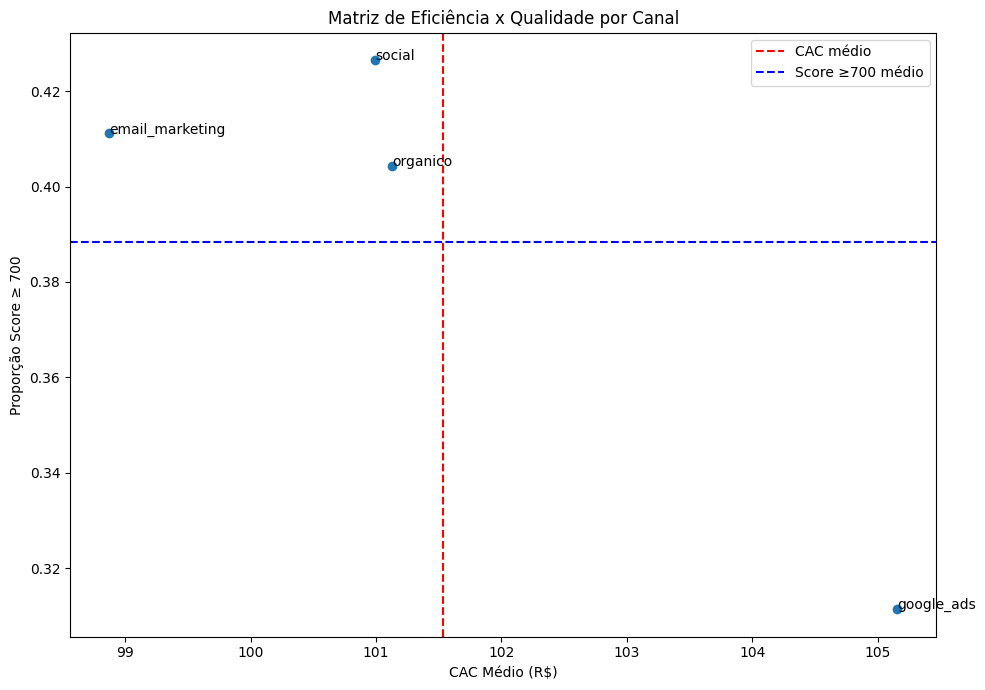

In [69]:
# calcular métricas necessárias
abt["score_alto"] = abt["score_credito"] >= 700

# cac médio
cac = abt.groupby("canal_aquisicao_principal")["custo_atribuido"].mean()

# proporção de score alto
prop_score = abt.groupby("canal_aquisicao_principal")["score_alto"].mean()

# plotar matriz
plt.figure(figsize=(10,7))

plt.scatter(cac, prop_score)

# anotar rótulos
for canal in cac.index:
    plt.annotate(canal, (cac[canal], prop_score[canal]), fontsize=10)

# linhas de referência (médias)
plt.axvline(cac.mean(), color="red", linestyle="--", label="CAC médio")
plt.axhline(prop_score.mean(), color="blue", linestyle="--", label="Score ≥700 médio")

plt.title("Matriz de Eficiência x Qualidade por Canal")
plt.xlabel("CAC Médio (R$)")
plt.ylabel("Proporção Score ≥ 700")
plt.legend()
plt.tight_layout()
plt.show()

A matriz Eficiência × Qualidade mostra que Email Marketing e Social são os canais mais eficientes para aquisição de clientes de alto score, combinando CAC competitivo com alta proporção de clientes de score ≥700.

Orgânico apresenta boa qualidade, mas não é escalável via investimento, atuando como canal de manutenção.

Google Ads aparece como o canal menos eficiente, com o CAC mais elevado e a menor taxa de clientes de alto score, sendo o principal candidato a otimização ou redução de investimento.

# **Campanhas que mais geram clientes com score ≥ 700**

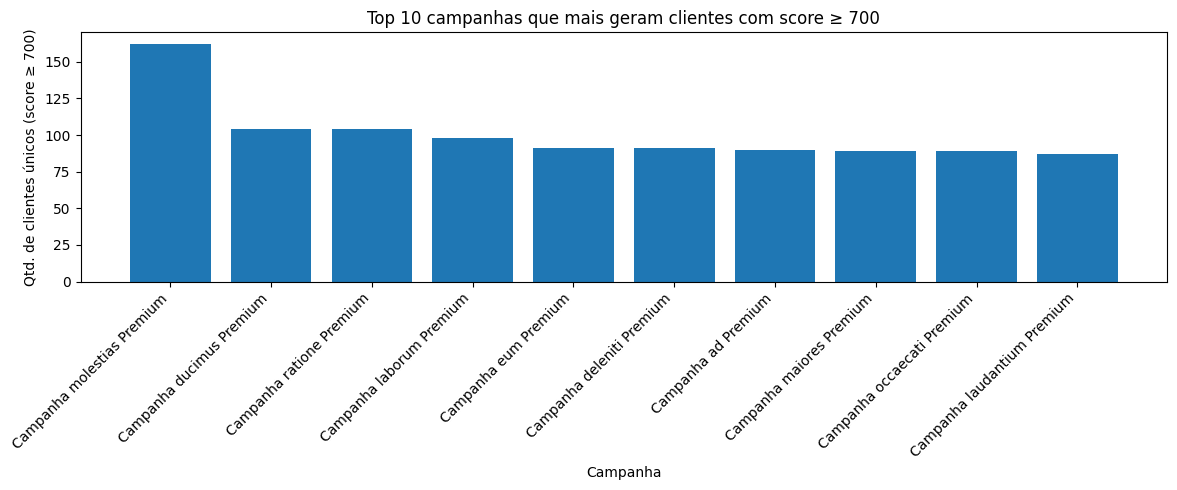

,id_cliente
nome_campanha,
Campanha molestias Premium,162
Campanha ducimus Premium,104
Campanha ratione Premium,104
Campanha laborum Premium,98
Campanha eum Premium,91
Campanha deleniti Premium,91
Campanha ad Premium,90
Campanha maiores Premium,89
Campanha occaecati Premium,89


In [70]:
# coluna auxiliar de score alto
abt["score_alto"] = abt["score_credito"] >= 700

# filtrar apenas clientes com score alto
abt_score_alto = abt[abt["score_alto"]]

# contar clientes únicos com score alto por campanha
clientes_score_alto_por_campanha = (
    abt_score_alto.groupby("nome_campanha")["id_cliente"]
    .nunique()
    .sort_values(ascending=False)
)

# opcional: TOP 10
top_n = 10
clientes_score_top = clientes_score_alto_por_campanha.head(top_n)

# gráfico
plt.figure(figsize=(12,5))
plt.bar(clientes_score_top.index, clientes_score_top.values)
plt.title(f"Top {top_n} campanhas que mais geram clientes com score ≥ 700")
plt.xlabel("Campanha")
plt.ylabel("Qtd. de clientes únicos (score ≥ 700)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

clientes_score_top

A “Campanha molestias Premium” destaca-se como a principal geradora de clientes de alto score, com performance significativamente superior ao restante do portfólio.

Um segundo grupo — composto pelas campanhas “duciums Premium”, “ratione Premium” e “laborum Premium” — apresenta excelente desempenho, formando o núcleo das campanhas que justificam aumento ou manutenção de investimento.

As demais campanhas Premium, ainda que contribuam de forma consistente, formam um bloco de performance intermediária, sugerindo ações focadas em otimização de segmentação ao invés de expansão de verba.

Esse ranking reforça que o banco já possui campanhas altamente qualificadas e que parte significativa da melhoria de performance pode vir da redistribuição inteligente da verba entre os grupos identificados.

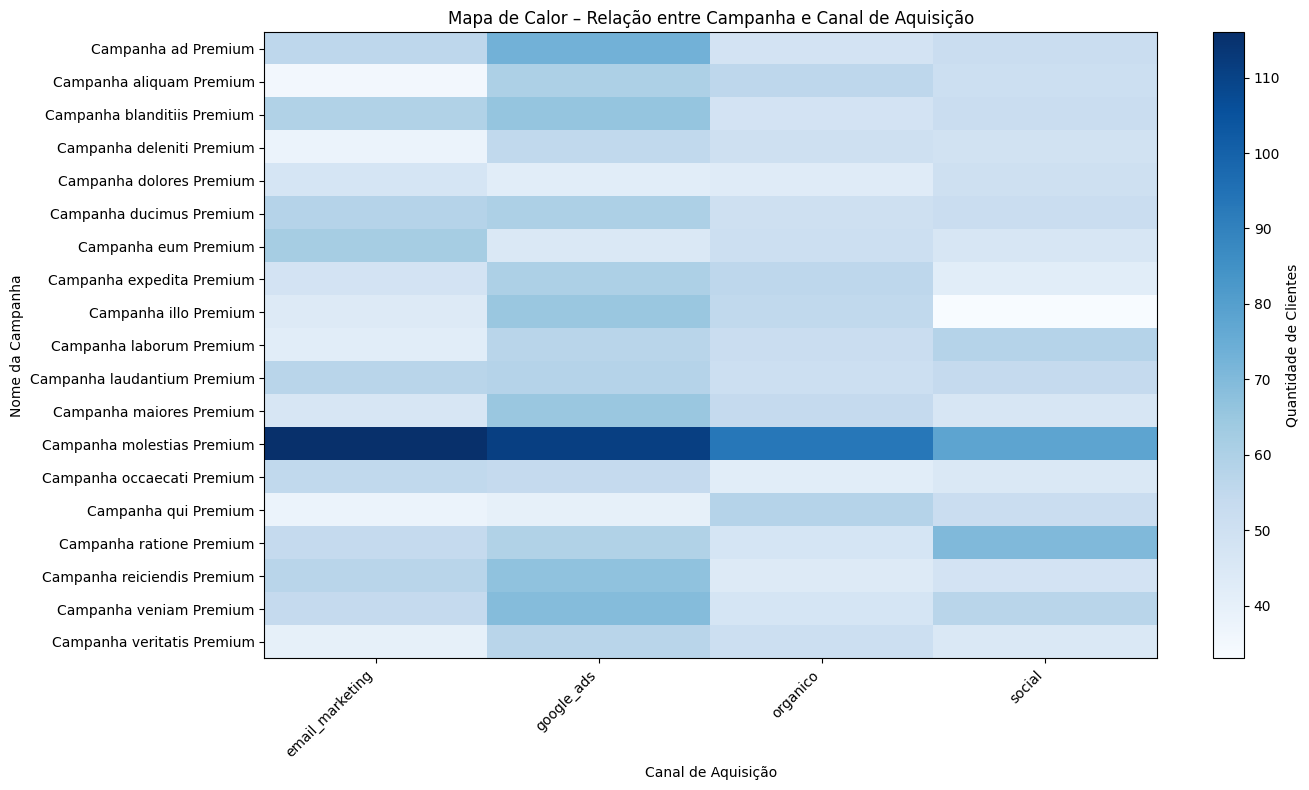

In [76]:

# criar tabela cruzada (contagem)
cross = pd.crosstab(abt["nome_campanha"], abt["canal_aquisicao_principal"])

plt.figure(figsize=(14,8))

# criar heatmap com matplotlib
plt.imshow(cross, cmap="Blues", aspect='auto')

plt.colorbar(label="Quantidade de Clientes")

# configurar eixos
plt.xticks(np.arange(len(cross.columns)), cross.columns, rotation=45, ha="right")
plt.yticks(np.arange(len(cross.index)), cross.index)

plt.title("Mapa de Calor – Relação entre Campanha e Canal de Aquisição")
plt.xlabel("Canal de Aquisição")
plt.ylabel("Nome da Campanha")

plt.tight_layout()
plt.show()

O heatmap evidencia que a “Campanha molestias Premium” é a mais robusta e amplamente distribuída entre os canais, o que explica seu destaque na geração de clientes de alta qualidade. Muitas outras campanhas apresentam forte concentração em canais específicos, especialmente Google Ads e orgânico, indicando segmentações mais restritas. Como Google Ads é o canal menos qualificado em termos de score, campanhas excessivamente dependentes dele podem estar limitando a capacidade de gerar clientes de score elevado. Uma redistribuição mais equilibrada para canais de maior qualidade, como Social e Email Marketing, pode melhorar a performance sem aumento significativo de CAC.

# **Campanhas com maior verba tendem a atrair clientes com score mais alto?**

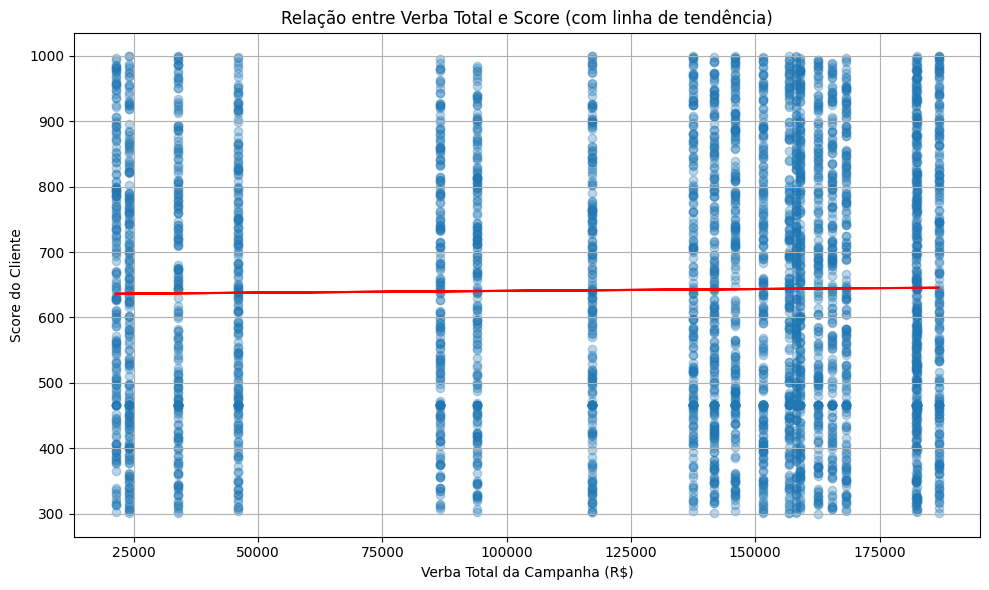

array([5.56657789e-05, 6.35144133e+02])

In [71]:
# remover nulos para regressão
df = abt[["verba_total", "score_credito"]].dropna()

# criar regressão linear
x = df["verba_total"]
y = df["score_credito"]

coef = np.polyfit(x, y, 1)
poly = np.poly1d(coef)

plt.figure(figsize=(10,6))

plt.scatter(x, y, alpha=0.3)
plt.plot(x, poly(x), color="red")  # linha de tendência

plt.title("Relação entre Verba Total e Score (com linha de tendência)")
plt.xlabel("Verba Total da Campanha (R$)")
plt.ylabel("Score do Cliente")
plt.grid(True)
plt.tight_layout()
plt.show()

coef

A análise bidimensional entre verba_total e score_credito demonstra que não existe correlação entre o tamanho do investimento de uma campanha e a qualidade dos clientes captados.
Clientes com score alto e baixo aparecem distribuídos ao longo de todas as faixas de verba.
A linha de tendência praticamente horizontal reforça que campanhas mais caras não geram clientes com melhor perfil de risco.

Portanto, aumentar investimento em uma campanha existente não necessariamente aumenta a proporção de clientes com score ≥ 700; a qualidade está mais relacionada ao canal e à segmentação da campanha, não ao valor investido.

# **Resumo Executivo – Direcionamento Estratégico de Verba por Canal**


---

A análise integrada dos dados de aquisição revela diferenças significativas entre os canais em termos de qualidade dos clientes (score ≥ 700), eficiência de custo (CAC) e capacidade de conversão. Esses insights permitem definir uma estratégia clara de rede alocação e reforço de investimento.

Canais que DEVEM receber maior verba
1. Social

Por quê?

É o canal com maior proporção de clientes de score ≥ 700, indicando excelente qualidade.

Apresenta CAC dentro da média e competitivo frente aos demais.

Mostrou alta densidade de scores elevados no scatter plot.

É consistente nas campanhas que mais performam, incluindo destaque nas melhores campanhas Premium.

Conclusão:
É o canal mais qualificado da operação.
Direcionar verba aqui aumenta a probabilidade de atingir o objetivo de +30% de clientes de score alto sem elevar o CAC.

2. Email Marketing

Por quê?

É o canal com melhor relação custo-benefício:
– CAC mais baixo entre os canais
– alta proporção de clientes com score alto

Converte bem clientes qualificados e aparece fortemente nas campanhas de melhor desempenho.

Indicou distribuição de score alta de forma consistente.

Conclusão:
É o canal mais eficiente financeiramente e de boa qualidade.
Reforçar investimento tende a gerar crescimento de score alto com impacto mínimo no CAC total.

Canais que DEVEM ter verba realocada / reduzida
3. Google Ads

Por quê?

Apresenta o maior CAC médio entre todos os canais.

É o canal com menor proporção de clientes com score ≥ 700.

Scatter plots mostram concentração visual maior em scores mais baixos.

Na matriz de eficiência x qualidade, aparece isolado no quadrante de pior desempenho (baixo score + alto CAC).

Muitas campanhas estão excessivamente concentradas nesse canal — o que limita resultados.

Conclusão:
Google Ads não é um bom destino de verba se o objetivo é qualidade.
É o principal candidato à redução ou redistribuição de investimento para canais mais qualificados.

Canais que DEVEM ser mantidos, não escalados
4. Orgânico

Por quê?

Tem qualidade razoável: proporção de score ≥700 levemente acima da média.

Mas não é escalável por investimento — não faz sentido aumentar verba aqui.

Está associado a volume estável, porém não influencia diretamente a estratégia de mídia.

Conclusão:
Deve ser mantido como está, sem redirecionamento de investimento.
Seu papel é complementar, mas não alavanca o resultado via verba.

